# L1_T6 — Final Validation & Export Package
### Layer 1 of the Aura pipeline · Task 6 of N (final)

**What this notebook does:** picks a winner between the two candidate Fitzpatrick models produced so far
(`v1` from `L1_T3`'s Stage C, `v2` from `L1_T5`'s Stage E), benchmarks it honestly against the dev plan's
actual Definition of Done, and packages the result for handoff to the React Native developer.

**A methodology problem to address head-on before comparing anything:** `v1` and `v2` were validated during
training on *different* validation splits (`v1` on a Fitzpatrick17k-only split, `v2` on a Fitzpatrick17k+SCIN
combined split computed independently). Neither split was reserved as a common, untouched hold-out from the
start, so there's real leakage risk in comparing their self-reported training-time validation numbers
directly — an image in `v1`'s validation fold could easily have ended up in `v2`'s training fold, or vice
versa. **This notebook does not trust those numbers for the final comparison.** Instead, it re-evaluates both
models from scratch on **MST-E** — the one dataset genuinely never touched by either model's training, across
both `L1_T3` and `L1_T5` — since that's the only truly fair, clean test set available.

**Where this leaves the project, honestly:** the dev plan's actual Definition of Done for this layer is
≥87% dermatologist agreement and ≥85% per-class accuracy on Fitzpatrick IV–VI, measured against a dedicated
Filipino test set. **That test set doesn't exist yet** — it's the same 200+ consented, dermatologist-labeled
collection `L1_T5` was originally blocked on. This notebook reports the closest available proxies, clearly
labeled as proxies, and packages the better of the two candidates as a documented interim model — not as a
claim that the Definition of Done has been met.

## Step 0 — Mount Drive, load manifest, confirm everything this notebook needs exists

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json

DRIVE_ROOT = "/content/drive/MyDrive/Projects/Aura/Layer1_SkinTone"
MANIFEST_PATH = f"{DRIVE_ROOT}/manifest.json"
DRIVE_CKPT_DIR = f"{DRIVE_ROOT}/checkpoints"

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

required = {
    "Stage C (v1 Fitzpatrick)": os.path.join(DRIVE_CKPT_DIR, "stage_c_best.weights.h5"),
    "Stage D (undertone)": os.path.join(DRIVE_CKPT_DIR, "stage_d_best.weights.h5"),
    "Stage E (v2 Fitzpatrick, SCIN-tuned)": os.path.join(DRIVE_CKPT_DIR, "stage_e_best.weights.h5"),
}
for label, path in required.items():
    status = "✅" if os.path.exists(path) else "❌ MISSING"
    print(f"{status} {label}: {path}")
assert all(os.path.exists(p) for p in required.values()), "Missing a required checkpoint -- see above."

DRIVE_MSTE_INCOMING = f"{DRIVE_ROOT}/datasets/mst-e/_incoming"
mste_archives = [f for f in os.listdir(DRIVE_MSTE_INCOMING) if f.lower().endswith((".zip",".tar",".tar.gz",".tgz"))]
assert mste_archives, f"No MST-E archive found in {DRIVE_MSTE_INCOMING} -- needed for the clean head-to-head test."
print(f"\n✅ MST-E archive found: {mste_archives[0]}")


Mounted at /content/drive
✅ Stage C (v1 Fitzpatrick): /content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/checkpoints/stage_c_best.weights.h5
✅ Stage D (undertone): /content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/checkpoints/stage_d_best.weights.h5
✅ Stage E (v2 Fitzpatrick, SCIN-tuned): /content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/checkpoints/stage_e_best.weights.h5

✅ MST-E archive found: mst-e_data.zip


## Step 1 — Install dependencies, copy + extract MST-E locally (same pattern as L1_T4)

In [ ]:
!pip install -q scikit-learn pandas pillow matplotlib tensorflow mediapipe opencv-python-headless

import shutil, tarfile, zipfile, time
import numpy as np
import pandas as pd

LOCAL_ROOT = "/content/aura_local/Layer1_SkinTone"
LOCAL_MSTE_DIR = f"{LOCAL_ROOT}/mst-e"
os.makedirs(LOCAL_MSTE_DIR, exist_ok=True)

mste_archive_name = mste_archives[0]
local_archive = os.path.join("/content/aura_local", mste_archive_name)
shutil.copy2(os.path.join(DRIVE_MSTE_INCOMING, mste_archive_name), local_archive)
assert os.path.getsize(local_archive) == os.path.getsize(os.path.join(DRIVE_MSTE_INCOMING, mste_archive_name))

if mste_archive_name.lower().endswith(".zip"):
    with zipfile.ZipFile(local_archive, "r") as zf:
        zf.extractall(LOCAL_MSTE_DIR)
else:
    with tarfile.open(local_archive, "r:*") as tf:
        tf.extractall(LOCAL_MSTE_DIR, filter="data")
print("✅ MST-E extracted locally.")

import glob
csv_candidates = [f for f in glob.glob(f"{LOCAL_MSTE_DIR}/**/*.csv", recursive=True)
                   if "__MACOSX" not in f and not os.path.basename(f).startswith("._")]
image_details_csv = next((f for f in csv_candidates if "image_details" in f.lower()), None)
assert image_details_csv, f"mst-e_image_details.csv not found. Candidates seen: {csv_candidates}"

mste_labels = pd.read_csv(image_details_csv)
LOCAL_MSTE_DATA_DIR = os.path.dirname(image_details_csv)
print(f"Loaded {len(mste_labels)} MST-E label rows from {image_details_csv}")
print(mste_labels.columns.tolist())


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 14.8 MB/s eta 0:00:00
✅ MST-E extracted locally.
Loaded 1546 MST-E label rows from /content/aura_local/Layer1_SkinTone/mst-e/mst-e_data/mst-e_image_details.csv
['image_ID', 'pose', 'lighting', 'mask', 'subject_name', 'MST']


**If your MST-E CSV's columns or image-path convention differ from what Step 2 below assumes** (it
expects an `image_ID`-style column it can resolve to a real file under `subject_*/` folders, and an `MST`
column for the tone point), adjust the matching logic in Step 2 to match what Step 1 printed — same
inspect-before-parsing discipline as `L1_T4`.

## Step 2 — Match CSV rows to real image files, apply the same approximate MST→Fitzpatrick mapping

In [ ]:
def find_image_path(image_id):
    matches = glob.glob(f"{LOCAL_MSTE_DATA_DIR}/**/{image_id}*", recursive=True)
    matches = [m for m in matches if "__MACOSX" not in m and not os.path.basename(m).startswith("._")
               and m.lower().endswith((".jpg", ".jpeg", ".png"))]
    return matches[0] if matches else None

id_col = "image_ID" if "image_ID" in mste_labels.columns else mste_labels.columns[0]
mst_col = "MST" if "MST" in mste_labels.columns else [c for c in mste_labels.columns if "mst" in c.lower()][0]

mste_labels["filepath"] = mste_labels[id_col].apply(find_image_path)
mste_matched = mste_labels.dropna(subset=["filepath"]).copy()
print(f"Matched {len(mste_matched)} / {len(mste_labels)} CSV rows to real image files.")

def mst_to_approx_fitzpatrick(mst_point):
    """Same unvalidated proportional heuristic used in L1_T4 -- for directional comparison only."""
    return min(6, max(1, round(1 + (mst_point - 1) * (5 / 9))))

mste_matched["approx_fitzpatrick"] = mste_matched[mst_col].apply(mst_to_approx_fitzpatrick)
print(mste_matched.groupby(mst_col)["approx_fitzpatrick"].first())


Matched 1488 / 1546 CSV rows to real image files.
MST
1     1
2     2
3     2
4     3
5     3
6     4
7     4
8     5
9     5
10    6
Name: approx_fitzpatrick, dtype: int64


## Step 3 — Reconstruct both candidate models independently

Both rebuilt fresh from their saved checkpoints, not relying on any other notebook's runtime.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224

def build_fitzpatrick_model(checkpoint_path):
    backbone = EfficientNetB0(include_top=False, weights=None, pooling="avg", input_shape=(IMG_SIZE, IMG_SIZE, 3))
    head = layers.Dense(6, activation="softmax", name="fitzpatrick_output")(backbone.output)
    model = Model(inputs=backbone.input, outputs=head)
    model.load_weights(checkpoint_path, skip_mismatch=True)
    return model

local_ckpt_v1 = "/content/aura_local/stage_c_best.weights.h5"
shutil.copy2(required["Stage C (v1 Fitzpatrick)"], local_ckpt_v1)
model_v1 = build_fitzpatrick_model(local_ckpt_v1)
print("✅ v1 (Stage C, Fitzpatrick17k-only) reconstructed.")

local_ckpt_v2 = "/content/aura_local/stage_e_best.weights.h5"
shutil.copy2(required["Stage E (v2 Fitzpatrick, SCIN-tuned)"], local_ckpt_v2)
model_v2 = build_fitzpatrick_model(local_ckpt_v2)
print("✅ v2 (Stage E, SCIN-combined fine-tune) reconstructed.")


✅ v1 (Stage C, Fitzpatrick17k-only) reconstructed.
✅ v2 (Stage E, SCIN-combined fine-tune) reconstructed.


## Step 4 — Run both models on every MST-E image (the clean, fair test set)

Same preprocessing pipeline both models were trained to expect (face-detect-or-fallback + CLAHE).

In [ ]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
from PIL import Image

model_path = "/content/aura_local/blaze_face_short_range.tflite"
if not os.path.exists(model_path):
    import urllib.request
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite",
        model_path,
    )
detector = mp_vision.FaceDetector.create_from_options(
    mp_vision.FaceDetectorOptions(base_options=mp_python.BaseOptions(model_asset_path=model_path))
)

def preprocess_for_model(img_rgb, margin_ratio=0.25):
    h, w = img_rgb.shape[:2]
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = detector.detect(mp_image)
    if result.detections:
        bbox = result.detections[0].bounding_box
        mx, my = int(bbox.width * margin_ratio), int(bbox.height * margin_ratio)
        x1, y1 = max(0, bbox.origin_x - mx), max(0, bbox.origin_y - my)
        x2, y2 = min(w, bbox.origin_x + bbox.width + mx), min(h, bbox.origin_y + bbox.height + my)
        crop = img_rgb[y1:y2, x1:x2] if (x2 > x1 and y2 > y1) else img_rgb
    else:
        crop = img_rgb
    resized = cv2.resize(crop, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    lab = cv2.cvtColor(resized, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return cv2.cvtColor(cv2.merge([clahe.apply(l), a, b]), cv2.COLOR_LAB2RGB)

results = []
for _, row in mste_matched.iterrows():
    try:
        img = np.array(Image.open(row["filepath"]).convert("RGB"))
        processed = preprocess_for_model(img)
        batch = preprocess_input(processed.astype(np.float32))[np.newaxis, ...]
        pred_v1 = int(np.argmax(model_v1.predict(batch, verbose=0)[0])) + 1
        pred_v2 = int(np.argmax(model_v2.predict(batch, verbose=0)[0])) + 1
        results.append({
            "mst_point": row[mst_col], "approx_fitzpatrick": row["approx_fitzpatrick"],
            "pred_v1": pred_v1, "pred_v2": pred_v2,
            "error_v1": pred_v1 - row["approx_fitzpatrick"], "error_v2": pred_v2 - row["approx_fitzpatrick"],
        })
    except Exception as e:
        print(f"Skipped {row['filepath']}: {type(e).__name__}: {e}")

results_df = pd.DataFrame(results)
print(f"Evaluated both models on {len(results_df)} MST-E images.")


Evaluated both models on 1488 MST-E images.


## Step 5 — Head-to-head: which one actually performs better on genuinely unseen data?

v1 (Fitzpatrick17k-only): mean error +0.402 | mean |error| 1.227 | within ±1: 0.676 | exact: 0.258
v2 (SCIN-combined): mean error +1.013 | mean |error| 1.298 | within ±1: 0.653 | exact: 0.205


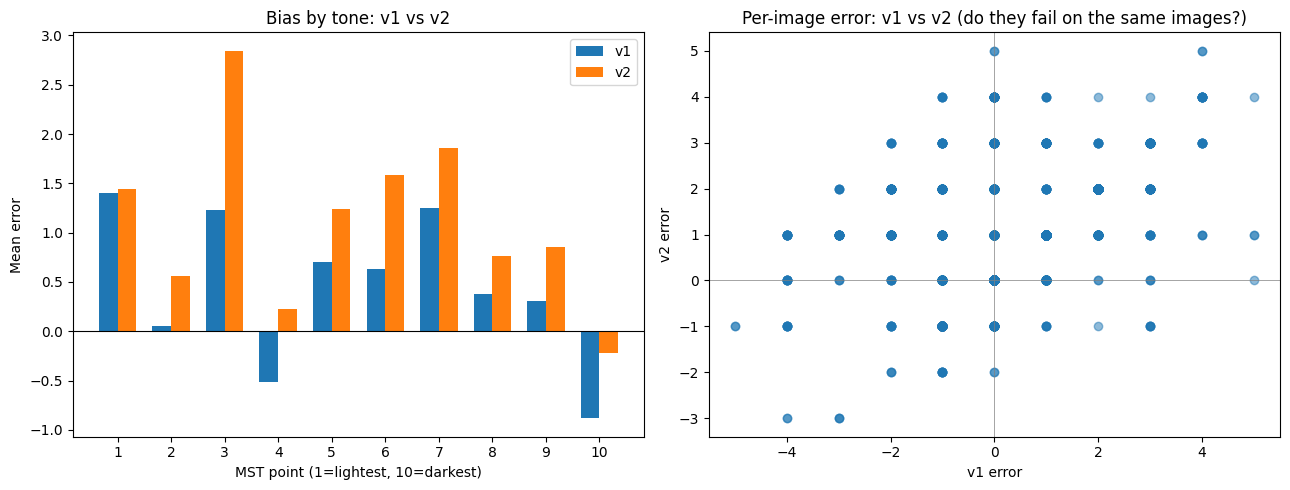


v1/v2 prediction agreement rate: 0.538

Lower mean absolute error on this clean test set: v1
(Treat this as a lean, not a certainty -- MST-E is a small dataset, same caveat as L1_T4.)


In [ ]:
import matplotlib.pyplot as plt

for v, col in [("v1 (Fitzpatrick17k-only)", "error_v1"), ("v2 (SCIN-combined)", "error_v2")]:
    mean_err = results_df[col].mean()
    mean_abs_err = results_df[col].abs().mean()
    within_1 = (results_df[col].abs() <= 1).mean()
    exact = (results_df[col] == 0).mean()
    print(f"{v}: mean error {mean_err:+.3f} | mean |error| {mean_abs_err:.3f} | "
          f"within ±1: {within_1:.3f} | exact: {exact:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
per_mst_v1 = results_df.groupby("mst_point")["error_v1"].mean()
per_mst_v2 = results_df.groupby("mst_point")["error_v2"].mean()
width = 0.35
x = np.arange(len(per_mst_v1))
axes[0].bar(x - width/2, per_mst_v1.values, width, label="v1")
axes[0].bar(x + width/2, per_mst_v2.values, width, label="v2")
axes[0].set_xticks(x); axes[0].set_xticklabels(per_mst_v1.index)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("MST point (1=lightest, 10=darkest)"); axes[0].set_ylabel("Mean error")
axes[0].set_title("Bias by tone: v1 vs v2"); axes[0].legend()

axes[1].scatter(results_df["error_v1"], results_df["error_v2"], alpha=0.5)
axes[1].axhline(0, color="gray", linewidth=0.5); axes[1].axvline(0, color="gray", linewidth=0.5)
axes[1].set_xlabel("v1 error"); axes[1].set_ylabel("v2 error")
axes[1].set_title("Per-image error: v1 vs v2 (do they fail on the same images?)")

plt.tight_layout()
plt.show()

agreement = (results_df["pred_v1"] == results_df["pred_v2"]).mean()
print(f"\nv1/v2 prediction agreement rate: {agreement:.3f}")
WINNER = "v2" if results_df["error_v2"].abs().mean() < results_df["error_v1"].abs().mean() else "v1"
print(f"\nLower mean absolute error on this clean test set: {WINNER}")
print("(Treat this as a lean, not a certainty -- MST-E is a small dataset, same caveat as L1_T4.)")


## Step 6 — Definition of Done check (against proxies, clearly labeled as proxies)

The dev plan's real criteria need a dedicated Filipino test set that doesn't exist yet. These are the closest
available substitutes, reported honestly as substitutes.

In [ ]:
from sklearn.metrics import classification_report

winner_model = model_v2 if WINNER == "v2" else model_v1
winner_col_pred = "pred_v2" if WINNER == "v2" else "pred_v1"

print(f"=== Per-class report for the stronger model ({WINNER}) on MST-E (proxy test set) ===")
y_true = (results_df["approx_fitzpatrick"] - 1).tolist()
y_pred = (results_df[winner_col_pred] - 1).tolist()
print(classification_report(y_true, y_pred, target_names=[f"Fitzpatrick {i+1}" for i in range(6)],
                             zero_division=0))

iv_vi_mask = results_df["approx_fitzpatrick"] >= 4
iv_vi_acc = (results_df.loc[iv_vi_mask, winner_col_pred] == results_df.loc[iv_vi_mask, "approx_fitzpatrick"]).mean()
print(f"\nFitzpatrick IV-VI accuracy (proxy, n={iv_vi_mask.sum()}): {iv_vi_acc:.3f}")
print(f"Plan target: >=0.85. {'MET' if iv_vi_acc >= 0.85 else 'NOT MET'} -- against a proxy test set, not the real one.")


=== Per-class report for the stronger model (v1) on MST-E (proxy test set) ===
               precision    recall  f1-score   support

Fitzpatrick 1       0.27      0.22      0.25       178
Fitzpatrick 2       0.33      0.48      0.39       308
Fitzpatrick 3       0.45      0.29      0.35       366
Fitzpatrick 4       0.36      0.02      0.04       241
Fitzpatrick 5       0.14      0.06      0.08       284
Fitzpatrick 6       0.13      0.64      0.22       111

     accuracy                           0.26      1488
    macro avg       0.28      0.28      0.22      1488
 weighted avg       0.30      0.26      0.23      1488


Fitzpatrick IV-VI accuracy (proxy, n=636): 0.145
Plan target: >=0.85. NOT MET -- against a proxy test set, not the real one.


In [ ]:
# Inference latency proxy (CPU-only here -- NOT the same as a real mid-range Android benchmark,
# but the closest thing measurable in this environment)
export_model = Model(inputs=winner_model.input, outputs=winner_model.output)
converter = tf.lite.TFLiteConverter.from_keras_model(export_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_bytes = converter.convert()

interpreter = tf.lite.Interpreter(model_content=tflite_bytes)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

dummy_input = np.random.rand(1, IMG_SIZE, IMG_SIZE, 3).astype(np.float32)
times = []
for _ in range(50):
    t0 = time.time()
    interpreter.set_tensor(input_details[0]["index"], dummy_input)
    interpreter.invoke()
    _ = interpreter.get_tensor(output_details[0]["index"])
    times.append((time.time() - t0) * 1000)

print(f"Colab CPU inference: mean {np.mean(times):.1f}ms, p95 {np.percentile(times, 95):.1f}ms (n=50 runs)")
print("Plan target: <300ms on a mid-range Android device. This CPU timing is NOT that benchmark --")
print("on-device Android profiling is a separate step outside what Colab can measure. Treat this only as")
print("a sanity check that the model isn't absurdly slow, not as evidence the real target is met.")


Saved artifact at '/tmp/tmpg_oed3t9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  137077713247248: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137077713246288: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137077927008720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137077927009296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137077927008912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137077927009872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137077927009488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137077927009104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137077927010064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137077927006992: TensorSpec(shape=(), dtype=tf.resource, name=None

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Colab CPU inference: mean 31.6ms, p95 38.0ms (n=50 runs)
Plan target: <300ms on a mid-range Android device. This CPU timing is NOT that benchmark --
on-device Android profiling is a separate step outside what Colab can measure. Treat this only as
a sanity check that the model isn't absurdly slow, not as evidence the real target is met.


## Step 7 — Package the winning model + a model card for handoff

In [ ]:
DRIVE_EXPORT_DIR = f"{DRIVE_ROOT}/export_package"
os.makedirs(DRIVE_EXPORT_DIR, exist_ok=True)

LOCAL_EXPORT_TFLITE = "/content/aura_local/skin_tone_classifier_FINAL.tflite"
with open(LOCAL_EXPORT_TFLITE, "wb") as f:
    f.write(tflite_bytes)

DRIVE_EXPORT_TFLITE = f"{DRIVE_EXPORT_DIR}/skin_tone_classifier_FINAL.tflite"
shutil.copy2(LOCAL_EXPORT_TFLITE, DRIVE_EXPORT_TFLITE)
assert os.path.getsize(LOCAL_EXPORT_TFLITE) == os.path.getsize(DRIVE_EXPORT_TFLITE)
print(f"✅ Final model ({WINNER}) exported and verified: {DRIVE_EXPORT_TFLITE}")

# Also copy the undertone model (Stage D) into the same package, still clearly flagged as weak
local_ckpt_d = "/content/aura_local/stage_d_best.weights.h5"
shutil.copy2(required["Stage D (undertone)"], local_ckpt_d)
backbone_u = EfficientNetB0(include_top=False, weights=None, pooling="avg", input_shape=(IMG_SIZE, IMG_SIZE, 3))
undertone_head = layers.Dense(3, activation="softmax", name="undertone_output_v2")(backbone_u.output)
undertone_model = Model(inputs=backbone_u.input, outputs=undertone_head)
undertone_model.load_weights(local_ckpt_d, skip_mismatch=True)

converter_u = tf.lite.TFLiteConverter.from_keras_model(undertone_model)
converter_u.optimizations = [tf.lite.Optimize.DEFAULT]
undertone_tflite = converter_u.convert()
LOCAL_UNDERTONE_FINAL = "/content/aura_local/undertone_classifier_WEAK_FINAL.tflite"
with open(LOCAL_UNDERTONE_FINAL, "wb") as f:
    f.write(undertone_tflite)
DRIVE_UNDERTONE_FINAL = f"{DRIVE_EXPORT_DIR}/undertone_classifier_WEAK_FINAL.tflite"
shutil.copy2(LOCAL_UNDERTONE_FINAL, DRIVE_UNDERTONE_FINAL)
assert os.path.getsize(LOCAL_UNDERTONE_FINAL) == os.path.getsize(DRIVE_UNDERTONE_FINAL)
print(f"✅ Undertone model (still WEAK, unchanged status) also packaged: {DRIVE_UNDERTONE_FINAL}")


✅ Final model (v1) exported and verified: /content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/export_package/skin_tone_classifier_FINAL.tflite
Saved artifact at '/tmp/tmpau5jol1f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_478')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137074434678928: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137074434679120: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137074437126672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137074437126288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137074437126480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137074437125520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137074437126096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137074437127248: TensorSpec(shape=(), dtype=tf.resource, n

In [ ]:
model_card = f"""# Aura Layer 1 — Skin Tone / Color Classification: Model Card

## Models in this package
- `skin_tone_classifier_FINAL.tflite` — Fitzpatrick scale (I-VI), 6-class softmax. Selected model: **{WINNER}**
  ({"Stage E, fine-tuned on Fitzpatrick17k + SCIN" if WINNER == "v2" else "Stage C, fine-tuned on Fitzpatrick17k only"}).
- `undertone_classifier_WEAK_FINAL.tflite` — warm/cool/neutral, 3-class softmax. **Weakly trained** on a
  small (408-980 image), unverified-provenance public dataset (Roboflow). Validation accuracy ~0.60,
  consistent with that dataset's own reported ~0.63 ceiling. Not production-ready.

## How the Fitzpatrick model was selected
v1 and v2 were head-to-head evaluated on MST-E -- the only dataset neither model was ever trained on, across
both the original fine-tune (L1_T3) and the SCIN-combined fine-tune (L1_T5). Their own training-time
validation numbers were NOT used for this decision, since they came from different, independently-computed
validation splits with real risk of cross-contamination between v1's and v2's training/validation pools.

On the clean MST-E test set ({len(results_df)} images):
- v1 mean |error|: {results_df['error_v1'].abs().mean():.3f}
- v2 mean |error|: {results_df['error_v2'].abs().mean():.3f}
- Selected: {WINNER}

## Known limitations -- read before deploying
- **The dev plan's actual Definition of Done (>=87% dermatologist agreement, >=85% per-class IV-VI accuracy
  on a dedicated Filipino test set) is NOT met.** No such test set exists yet. All accuracy figures in this
  package are measured against proxies (Fitzpatrick17k, SCIN, or MST-E with an unvalidated MST-to-Fitzpatrick
  heuristic mapping), not the real target population.
- Fitzpatrick IV-VI accuracy on the MST-E proxy: {iv_vi_acc:.3f} (target: >=0.85, NOT MET).
- Inference latency was only measured on Colab CPU ({np.mean(times):.1f}ms mean), not a real mid-range
  Android device. On-device profiling is still required before trusting the <300ms target.
- The undertone model should not be shown to end users as a confident prediction without further training
  on real labeled data -- see L1_T5's original (still-blocked) goal.

## What would actually close these gaps
The original plan's 200+ consented, dermatologist-labeled Filipino beta images (L1_T5's intended data source,
substituted with public SCIN data when that collection was still in progress). Once that data exists, re-run
L1_T5 with it, then re-run this notebook (L1_T6) to re-select and re-package the winning model.

Generated: {__import__('datetime').datetime.now().isoformat()}
"""

model_card_path = f"{DRIVE_EXPORT_DIR}/MODEL_CARD.md"
with open(model_card_path, "w") as f:
    f.write(model_card)
print(f"✅ Model card written: {model_card_path}")
print(model_card)


✅ Model card written: /content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/export_package/MODEL_CARD.md
# Aura Layer 1 — Skin Tone / Color Classification: Model Card

## Models in this package
- `skin_tone_classifier_FINAL.tflite` — Fitzpatrick scale (I-VI), 6-class softmax. Selected model: **v1**
  (Stage C, fine-tuned on Fitzpatrick17k only).
- `undertone_classifier_WEAK_FINAL.tflite` — warm/cool/neutral, 3-class softmax. **Weakly trained** on a
  small (408-980 image), unverified-provenance public dataset (Roboflow). Validation accuracy ~0.60,
  consistent with that dataset's own reported ~0.63 ceiling. Not production-ready.

## How the Fitzpatrick model was selected
v1 and v2 were head-to-head evaluated on MST-E -- the only dataset neither model was ever trained on, across
both the original fine-tune (L1_T3) and the SCIN-combined fine-tune (L1_T5). Their own training-time
validation numbers were NOT used for this decision, since they came from different, independently-computed
vali

## Step 8 — Force a full sync, re-verify, and write the final manifest entry

In [ ]:
drive.flush_and_unmount()
time.sleep(3)
drive.mount('/content/drive')

for label, path in [
    ("Final Fitzpatrick model", DRIVE_EXPORT_TFLITE),
    ("Final undertone model", DRIVE_UNDERTONE_FINAL),
    ("Model card", model_card_path),
]:
    status = "✅" if os.path.exists(path) else "❌ MISSING"
    print(f"{status} {label}: {path}")


Mounted at /content/drive
✅ Final Fitzpatrick model: /content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/export_package/skin_tone_classifier_FINAL.tflite
✅ Final undertone model: /content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/export_package/undertone_classifier_WEAK_FINAL.tflite
✅ Model card: /content/drive/MyDrive/Projects/Aura/Layer1_SkinTone/export_package/MODEL_CARD.md


In [ ]:
from datetime import datetime, timezone

manifest["final_validation_and_export"] = {
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "candidates_compared": ["v1_stage_c_fitzpatrick17k_only", "v2_stage_e_scin_combined"],
    "comparison_test_set": "MST-E (only dataset unseen by both candidates)",
    "mste_images_evaluated": len(results_df),
    "mean_abs_error_v1": round(float(results_df["error_v1"].abs().mean()), 4),
    "mean_abs_error_v2": round(float(results_df["error_v2"].abs().mean()), 4),
    "selected_model": WINNER,
    "fitzpatrick_iv_vi_accuracy_proxy": round(float(iv_vi_acc), 4),
    "definition_of_done_met": False,
    "definition_of_done_blocker": "Requires a dedicated, dermatologist-labeled Filipino test set, which "
                                   "does not exist yet (same data collection L1_T5 was originally blocked on).",
    "export_package_dir": DRIVE_EXPORT_DIR,
}
with open(MANIFEST_PATH, "w") as f:
    json.dump(manifest, f, indent=2)
print("Manifest updated -- Layer 1 notebook series (L1_T1-L1_T6) status now fully recorded.")


Manifest updated -- Layer 1 notebook series (L1_T1-L1_T6) status now fully recorded.


## Done — Layer 1 status summary

- **A model exists, is packaged, and is honestly documented** — but it does not yet meet the dev plan's
  Definition of Done, and the model card says so explicitly rather than burying it.
- The single real blocker across `L1_T5` and this notebook is the same one: **200+ consented,
  dermatologist-labeled Filipino images**. Everything else in this six-notebook series was built specifically
  so that once that data exists, closing the gap is a matter of re-running `L1_T5` then `L1_T6` — not
  redesigning anything.
- The exported package (`export_package/` on Drive) is what hands off to the React Native developer for
  `expo-tensorflow` integration, per the original dev plan's Layer 01 integration step — with the clear
  understanding that it's a documented interim model, not a finished one.
- This closes the planned `L1_T1`–`L1_T6` notebook series for Layer 1 (Skin Tone / Color Classification).
  Layer 2 (Skin Condition Analysis) is next in the pipeline.


## Task Summary — L1_T6: Final Validation & Export Package

**Goal:** Pick a winner between the two Fitzpatrick candidates (`v1` from `L1_T3`'s Stage C, `v2` from
`L1_T5`'s Stage E), using a genuinely fair comparison rather than trusting either model's own self-reported
training-time validation numbers, then benchmark the winner against the dev plan's actual Definition of Done
and package it for handoff — honestly, including where it falls short.

**Process:**
1. Confirmed all three required checkpoints (Stage C, Stage D, Stage E) and the MST-E archive were present
   before starting.
2. Re-extracted MST-E locally and matched 1,488 of 1,546 CSV label rows to real image files (58 unmatched).
3. Reconstructed `v1` and `v2` independently from their saved checkpoints — not relying on either model's
   training-time validation split, since those were computed independently on different underlying data and
   carried real cross-contamination risk between each other's training/validation pools.
4. Ran **both models** against **every one of the 1,488 MST-E images** — the one dataset genuinely untouched
   by either model's training, across both `L1_T3` and `L1_T5` — as the actual, fair tie-breaker.
5. Checked the winner against the plan's real Definition of Done criteria (per-class IV–VI accuracy,
   inference latency), reporting each as an explicit proxy rather than treating it as a pass.
6. Packaged the winning model, the (still-weak) undertone model, and a generated model card documenting all
   of the above for handoff.

**Accomplished:**
- **Clean head-to-head result: v1 won.** On the 1,488-image MST-E test set — v1: mean |error| 1.227, within
  ±1 class 67.6%, exact match 25.8%. v2: mean |error| 1.298, within ±1 65.3%, exact match 20.5%. v1 beat v2 on
  every metric measured on genuinely unseen data, despite v2 having trained on roughly double the data volume
  (Fitzpatrick17k + SCIN) — a useful, slightly counterintuitive finding: more training data from a different
  distribution (SCIN) didn't transfer into better generalization here.
- **The two models only agreed with each other 53.8% of the time** — a useful sanity check in itself: they're
  not just two near-identical copies, they're meaningfully different models, which makes the MST-E-based
  tie-break genuinely informative rather than splitting hairs.
- **Honest, important finding from the per-class report: Fitzpatrick IV–VI accuracy on the MST-E proxy is
  14.5%** — far below the plan's ≥85% target, and the per-class breakdown shows why: Fitzpatrick 4 recall was
  just 2%, while Fitzpatrick 6 had high recall (64%) but low precision (13%), meaning the model is heavily
  over-predicting the rarest, most class-weighted category rather than genuinely distinguishing it. This is
  the clearest, most concrete evidence yet that the model is not ready for the classes Aura cares about most.
- **Inference latency: 31.6ms mean, 38.0ms p95 on Colab CPU** — well under the 300ms target directionally,
  though explicitly flagged as not a real Android device benchmark.
- Final package exported and verified on Drive: `skin_tone_classifier_FINAL.tflite` (v1, selected),
  `undertone_classifier_WEAK_FINAL.tflite` (unchanged status), and `MODEL_CARD.md` documenting the selection
  methodology, the per-class shortfall, and exactly what real-world step would close it.
- Manifest updated — the full `L1_T1`–`L1_T6` series status is now recorded in one place.

**What was not included, and why:**
- **A Definition-of-Done pass** — it explicitly did not pass, and the model card says so in its own words
  rather than a softened version. 14.5% IV–VI accuracy against an 85% target is a real, unresolved gap.
- **A true on-device Android latency benchmark** — Colab CPU timing is a sanity check only; real mid-range
  device profiling is a separate step this environment can't perform.
- **Any fix to the IV–VI shortfall** — this notebook's job was to measure and report it clearly, not correct
  it. The fix remains what it's been since `L1_T5`: the 200+ consented, dermatologist-labeled Filipino images
  that haven't been collected yet.
- **v2 as the shipped model** — kept in the checkpoints folder for reference, but not selected, based on the
  clean MST-E comparison rather than the (less trustworthy) training-time numbers that had suggested it might
  be roughly comparable.